In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

dataset = pd.read_csv("../dataset/featured_dataset.csv")

dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 539226 entries, 0 to 539225
Data columns (total 20 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   year               539226 non-null  int64  
 1   make               539226 non-null  object 
 2   model              539226 non-null  object 
 3   trim               539226 non-null  object 
 4   body               536458 non-null  object 
 5   transmission       476694 non-null  object 
 6   vin                539226 non-null  object 
 7   state              539226 non-null  object 
 8   condition          539226 non-null  float64
 9   odometer           539226 non-null  float64
 10  color              539226 non-null  object 
 11  interior           539226 non-null  object 
 12  seller             539226 non-null  object 
 13  mmr                539226 non-null  float64
 14  sellingprice       539226 non-null  float64
 15  saledate           539226 non-null  object 
 16  sa

In [92]:
dataset.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate,sale_year,vehicle_age,mmr_vs_sp,mmr_vs_sp_percent
0,2015,kia,sorento,lx,suv,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,2014-12-16 04:30:00+00:00,2014,-1,1000.0,4.88
1,2015,kia,sorento,lx,suv,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,2014-12-16 04:30:00+00:00,2014,-1,700.0,3.37
2,2014,bmw,3 series,328i sulev,sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,2015-01-14 20:30:00+00:00,2015,1,-1900.0,-5.96
3,2015,volvo,s60,t5,sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,2015-01-28 20:30:00+00:00,2015,0,250.0,0.91
4,2014,bmw,6 series gran coupe,650i,sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,2014-12-18 04:30:00+00:00,2014,0,1000.0,1.52


In [93]:
#1. Total revenue through years

dataset["sellingprice"].sum()

np.float64(7371675733.0)

In [94]:
#2. Total units sold through years.

dataset["vin"].size

539226

In [95]:
#3. Top 10 highest units sold company (all time).

top_10_vehicles = (dataset.groupby(["make"])["vin"]
                   .agg("count")
                   .sort_values(ascending = False)
                   .reset_index(name = "unit_sold")
                   .head(10))
top_10_vehicles

,make,unit_sold
0,ford,92311
1,chevrolet,59562
2,nissan,53297
3,toyota,39419
4,dodge,30460
5,honda,26966
6,hyundai,21578
7,bmw,20217
8,kia,17890
9,chrysler,17237


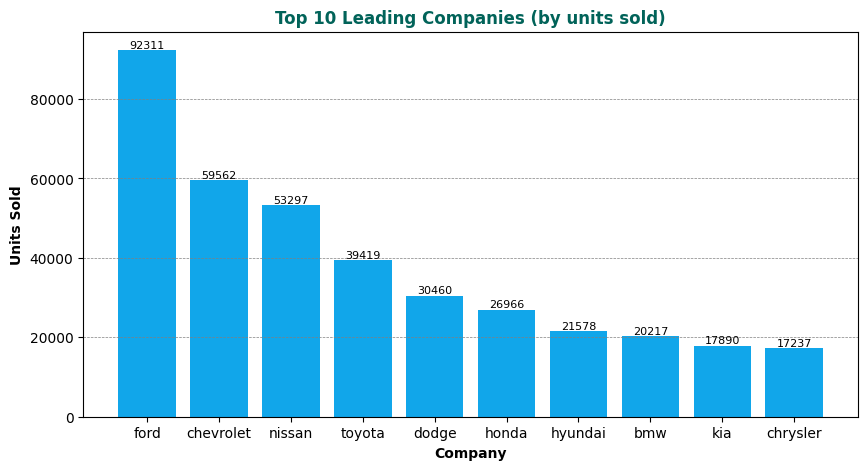

In [96]:
# plotting graph

x_axis = top_10_vehicles["make"]
y_axis = top_10_vehicles["unit_sold"]

plt.figure(figsize = (10, 5))

bars = plt.bar(x_axis, y_axis, color = "#11a6eaff")

plt.bar_label(bars, fontsize = 8)
plt.grid(axis = "y" , linestyle = "--", linewidth = 0.5, color = "grey")

plt.title("Top 10 Leading Companies (by units sold)", loc = "center", fontweight = "bold", color = "#016359")
plt.xlabel("Company", loc = "center", fontweight = "bold")
plt.ylabel("Units Sold", fontweight = "bold")

plt.show()

In [97]:
#4. Top 10 unit sold states (all time).

top_10_states = (dataset.groupby(["state"])["vin"]
                 .agg("count")
                 .sort_values(ascending = False)
                 .reset_index(name = "units_sold")
                 .head(10))
top_10_states

,state,units_sold
0,fl,80362
1,ca,70061
2,pa,52431
3,tx,44271
4,ga,33281
5,nj,27115
6,il,22987
7,oh,20789
8,nc,20747
9,tn,19875


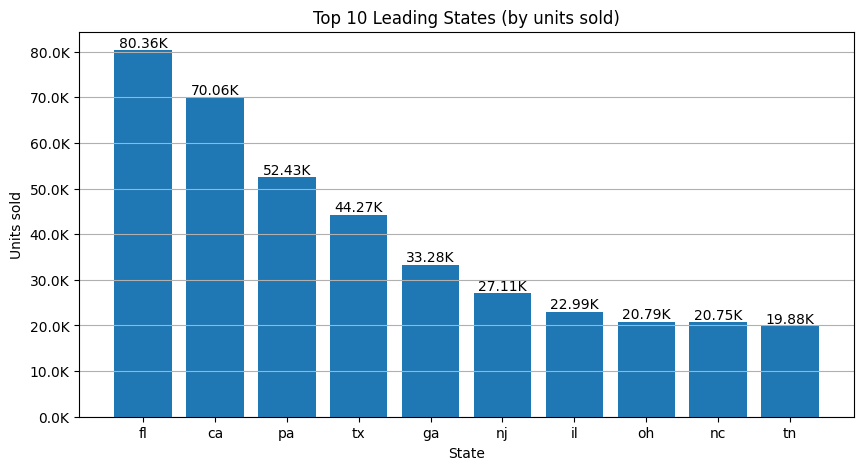

In [105]:
# plotting graph

x_axis = top_10_states["state"]
y_axis = top_10_states["units_sold"]

plt.figure(figsize = (10, 5))

bars = plt.bar(x_axis, y_axis)

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1000:.1f}K")
)

plt.grid(axis = "y")

plt.title("Top 10 Leading States (by units sold)")
plt.xlabel("State")
plt.ylabel("Units sold")

plt.bar_label(bars, 
              labels = [f"{x/1000:.2f}K" for x in bars.datavalues])

plt.show()

In [99]:
#5. Median age of vehicle (all time).

dataset["vehicle_age"].agg("median")

np.float64(3.0)

In [100]:
#6. Highest units sold vehicle [make, body, trim] (all time).

(dataset.groupby(["make", "model"])["vin"]
.agg("count")
.sort_values(ascending = False)
.reset_index(name = "unit_sold")
.head(10)
)

,make,model,unit_sold
0,nissan,altima,19176
1,ford,f-150,14119
2,ford,fusion,12754
3,toyota,camry,12414
4,ford,escape,11716
5,ford,focus,10262
6,honda,accord,9043
7,bmw,3 series,8050
8,dodge,grand caravan,7857
9,chevrolet,impala,7842
